## Notebook Contents

| Section | Description |
|---|---|
| 1 | Load dataset and fix dtypes |
| 2 | Feature definitions |
| 3 | Stratified 80/20 train/test split |
| 4 | Preprocessing pipeline |
| 5 | Stratified random baseline (DummyClassifier) |
| 6 | Logistic Regression |
| 7 | Decision Tree (max_depth = 10) |
| 8 | Model comparison — accuracy, macro F1, weighted F1 |
| 9 | Confusion matrices for both models |
| 10 | Macro F1 vs weighted F1 — why they differ |
| 11 | Failure-mode reflection |

**Reproducibility:**

| Parameter | Value |
|---|---|
| Random seed | `42` |
| Split | 80% train / 20% test, stratified on `esi` |
| Primary metric | Macro F1 (see Section 10 justification) |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score
)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', '{:.4f}'.format)

print(f"Libraries loaded. Random seed: {RANDOM_SEED}")

Libraries loaded. Random seed: 42


## Section 1 — Load Dataset

`df_raw` preserves the unmodified source. The blood glucose dtype
anomaly (column stored as object due to non-numeric entries such
as `'HIGH'`) identified in Week 5 profiling is corrected immediately
with `pd.to_numeric(..., errors='coerce')`.

In [2]:
df_raw = pd.read_csv("yaleemmlc_admissionprediction_triage.csv")

numeric_cols_to_fix = [
    "age", "esi",
    "triage_vital_hr", "triage_vital_sbp", "triage_vital_dbp",
    "triage_vital_rr", "triage_vital_o2",
    "triage_vital_temp", "triage_glucose"
]
for col in numeric_cols_to_fix:
    if col in df_raw.columns:
        df_raw[col] = pd.to_numeric(df_raw[col], errors="coerce")

print(f"Dataset loaded: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print(f"\nESI (target) distribution:")
print(df_raw['esi'].value_counts().sort_index().to_string())

Dataset loaded: 55,121 rows × 226 columns

ESI (target) distribution:
esi
1.0000       77
2.0000    17924
3.0000    27010
4.0000     8896
5.0000     1214


## Section 2 — Feature Definitions

Features are drawn from the top-10 shortlist in
`/docs/feature_shortlist.md`. Three feature types require
different preprocessing:

| Type | Features | Preprocessing |
|---|---|---|
| Numeric | SpO2, HR, SBP, RR, Temp, Age, Glucose | Median impute → StandardScaler |
| Binary | cc_shortnessofbreath | Mode impute (no scaling) |
| Categorical | arrivalmode, previousdispo | Mode impute → OneHotEncoder |

`triage_vital_dbp` is excluded: it is highly correlated with
`triage_vital_sbp` (Spearman rho = 0.63, Figure 5 correlation heatmap),
so including both adds multicollinearity without predictive gain.

In [3]:
NUMERIC_FEATURES = [
    "triage_vital_o2",   # Rank 1 — SpO2 (%)
    "triage_vital_hr",   # Rank 2 — Heart Rate (bpm)
    "triage_vital_sbp",  # Rank 3 — Systolic BP (mmHg)
    "triage_vital_rr",   # Rank 4 — Respiratory Rate (bpm)
    "triage_vital_temp", # Rank 5 — Temperature
    "age",               # Rank 6 — Age (years)
    "triage_glucose",    # Rank 8 — Blood Glucose
]
BINARY_FEATURES      = ["cc_shortnessofbreath"]   # Rank 9
CATEGORICAL_FEATURES = ["arrivalmode", "previousdispo"]  # Rank 7 & 10

TARGET_COL = "esi"

NUMERIC_FEATURES     = [c for c in NUMERIC_FEATURES     if c in df_raw.columns]
BINARY_FEATURES      = [c for c in BINARY_FEATURES      if c in df_raw.columns]
CATEGORICAL_FEATURES = [c for c in CATEGORICAL_FEATURES if c in df_raw.columns]
ALL_FEATURES = NUMERIC_FEATURES + BINARY_FEATURES + CATEGORICAL_FEATURES

df_model = df_raw[ALL_FEATURES + [TARGET_COL]].dropna(subset=[TARGET_COL]).copy()
df_model[TARGET_COL] = df_model[TARGET_COL].astype(int)

X = df_model[ALL_FEATURES]
y = df_model[TARGET_COL]

print(f"Modelling dataset: {df_model.shape[0]:,} rows, {len(ALL_FEATURES)} features")
print(f"Target classes   : {sorted(y.unique())}")

Modelling dataset: 55,121 rows, 10 features
Target classes   : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


## Section 3 — Stratified 80/20 Train/Test Split

Stratification on `esi` ensures each ESI class appears in training
and test at the same proportion as the full dataset. Without it,
rare classes — especially ESI 1 (life-threatening, only ~16 patients
in the test set) — could be absent from one split, making performance
evaluation impossible for the most clinically critical class.

`random_state=42` is set here and in all models. This value is
committed to the README so any reviewer can reproduce the exact split.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_SEED,
    stratify=y
)

ESI_CLASSES = sorted(y.unique().tolist())
ESI_LABELS  = [f"ESI {i}" for i in ESI_CLASSES]

print(f"Training set : {X_train.shape[0]:,} rows")
print(f"Test set     : {X_test.shape[0]:,} rows")

split_check = pd.DataFrame({
    "Original (%)": y.value_counts(normalize=True).sort_index().mul(100).round(2),
    "Train (%)":    y_train.value_counts(normalize=True).sort_index().mul(100).round(2),
    "Test (%)":     y_test.value_counts(normalize=True).sort_index().mul(100).round(2),
})
split_check.index.name = "ESI Level"
print("\nStratification check:")
print(split_check.to_string())

Training set : 44,096 rows
Test set     : 11,025 rows

Stratification check:
           Original (%)  Train (%)  Test (%)
ESI Level                                   
1                0.1400     0.1400    0.1500
2               32.5200    32.5200   32.5200
3               49.0000    49.0000   49.0000
4               16.1400    16.1400   16.1400
5                2.2000     2.2000    2.2000


## Section 4 — Preprocessing Pipeline

A `ColumnTransformer` applies the correct steps to each feature group:

- **Numeric:** Median imputation (robust to outliers identified in
  Week 5 boxplots) then Standard Scaling (required for logistic
  regression to prevent large-magnitude features dominating).
- **Binary:** Mode imputation only — the most frequent value is 0
  (complaint absent), which is clinically correct. Scaling not applied.
- **Categorical:** Mode imputation then one-hot encoding with
  `handle_unknown='ignore'` so unseen category values at test time
  do not crash the pipeline.

All transformers are fitted on `X_train` only. Fitting on the full
dataset before splitting would leak test-set statistics into training
and inflate reported performance.

In [5]:
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])
binary_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent'))
])
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer,     NUMERIC_FEATURES),
    ('bin', binary_transformer,      BINARY_FEATURES),
    ('cat', categorical_transformer, CATEGORICAL_FEATURES)
], remainder='drop')

print("ColumnTransformer ready.")


ColumnTransformer ready.


## Section 5 — Stratified Random Baseline (DummyClassifier)

Before training any real model, a `DummyClassifier` with
`strategy='stratified'` is fitted as a performance floor.
This classifier ignores all feature values and makes predictions
purely by sampling from the training class distribution at random.

**Clinical meaning:** Any real model that performs no better than
this baseline has learned nothing from the vital signs and should
not be deployed. A logistic regression or decision tree must
exceed this floor by a meaningful margin to justify the complexity
and clinical risk of using an AI tool.

In [6]:
dummy = DummyClassifier(strategy='stratified', random_state=RANDOM_SEED)
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

acc_dummy      = round(accuracy_score(y_test, y_pred_dummy), 4)
macro_f1_dummy = round(f1_score(y_test, y_pred_dummy, average='macro',
                                 labels=ESI_CLASSES, zero_division=0), 4)
wtd_f1_dummy   = round(f1_score(y_test, y_pred_dummy, average='weighted',
                                 labels=ESI_CLASSES, zero_division=0), 4)

print("DummyClassifier (stratified random) — test set results:")
print(f"  Accuracy       : {acc_dummy:.4f}")
print(f"  Macro F1       : {macro_f1_dummy:.4f}")
print(f"  Weighted F1    : {wtd_f1_dummy:.4f}")
print()
print(classification_report(y_test, y_pred_dummy,
      labels=ESI_CLASSES, target_names=ESI_LABELS, digits=4,
      zero_division=0))

DummyClassifier (stratified random) — test set results:
  Accuracy       : 0.3754
  Macro F1       : 0.2039
  Weighted F1    : 0.3746

              precision    recall  f1-score   support

       ESI 1     0.0000    0.0000    0.0000        16
       ESI 2     0.3337    0.3275    0.3306      3585
       ESI 3     0.4908    0.4981    0.4944      5402
       ESI 4     0.1471    0.1478    0.1475      1779
       ESI 5     0.0487    0.0453    0.0469       243

    accuracy                         0.3754     11025
   macro avg     0.2041    0.2037    0.2039     11025
weighted avg     0.3738    0.3754    0.3746     11025



## Section 6 — Logistic Regression

The logistic regression baseline from Week 6 (which scored 100/100
at interim assessment) is reproduced here unchanged for direct
comparison with the decision tree.

`class_weight='balanced'` corrects for ESI class imbalance by
penalising errors on rare classes proportionally more heavily.
Without this, the model optimises for ESI 3 (the majority class)
and achieves near-zero recall on ESI 1.

In [7]:
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(
        multi_class='multinomial',
        solver='lbfgs',
        max_iter=1000,
        class_weight='balanced',
        random_state=RANDOM_SEED,
        C=1.0
    ))
])

lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)

acc_lr      = round(accuracy_score(y_test, y_pred_lr), 4)
macro_f1_lr = round(f1_score(y_test, y_pred_lr, average='macro',
                               labels=ESI_CLASSES, zero_division=0), 4)
wtd_f1_lr   = round(f1_score(y_test, y_pred_lr, average='weighted',
                               labels=ESI_CLASSES, zero_division=0), 4)

print("Logistic Regression — test set results:")
print(f"  Accuracy       : {acc_lr:.4f}")
print(f"  Macro F1       : {macro_f1_lr:.4f}")
print(f"  Weighted F1    : {wtd_f1_lr:.4f}")
print()
print(classification_report(y_test, y_pred_lr,
      labels=ESI_CLASSES, target_names=ESI_LABELS, digits=4,
      zero_division=0))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Logistic Regression — test set results:
  Accuracy       : 0.2620
  Macro F1       : 0.2124
  Weighted F1    : 0.3221

              precision    recall  f1-score   support

       ESI 1     0.0055    0.8125    0.0109        16
       ESI 2     0.5028    0.2753    0.3558      3585
       ESI 3     0.5628    0.2282    0.3248      5402
       ESI 4     0.2636    0.2996    0.2805      1779
       ESI 5     0.0495    0.5062    0.0901       243

    accuracy                         0.2620     11025
   macro avg     0.2768    0.4244    0.2124     11025
weighted avg     0.4829    0.2620    0.3221     11025



## Section 7 — Decision Tree (max_depth = 10)

**max_depth justification:**

The default `max_depth=None` allows the tree to grow until all leaf
nodes are pure, which almost always produces severe overfitting —
the tree memorises training noise rather than learning generalisable
clinical patterns. For a dataset with 10 input features and 5 ESI
classes, a depth of 10 allows the tree to capture meaningful
multi-feature interactions (e.g. "high HR AND low SpO2 AND ambulance
arrival → ESI 2") across the full acuity spectrum, while limiting
the maximum number of leaf nodes to 1,024. This prevents the tree
from creating patient-specific rules that cannot generalise to new
presentations.

`max_depth=10` is chosen as a principled starting point for the
baseline; systematic cross-validated tuning over depths of 5, 10, 15,
and 20 is planned for the full stacked model in Week 7.

`class_weight='balanced'` is applied for the same reason as in the
logistic regression — to prevent the majority class (ESI 3) from
dominating the splitting criterion.

In [8]:
dt_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(
        max_depth=10,
        class_weight='balanced',
        criterion='gini',
        random_state=RANDOM_SEED
    ))
])

dt_pipeline.fit(X_train, y_train)
y_pred_dt = dt_pipeline.predict(X_test)

acc_dt      = round(accuracy_score(y_test, y_pred_dt), 4)
macro_f1_dt = round(f1_score(y_test, y_pred_dt, average='macro',
                               labels=ESI_CLASSES, zero_division=0), 4)
wtd_f1_dt   = round(f1_score(y_test, y_pred_dt, average='weighted',
                               labels=ESI_CLASSES, zero_division=0), 4)

print("Decision Tree (max_depth=10) — test set results:")
print(f"  Accuracy       : {acc_dt:.4f}")
print(f"  Macro F1       : {macro_f1_dt:.4f}")
print(f"  Weighted F1    : {wtd_f1_dt:.4f}")
print()
print(classification_report(y_test, y_pred_dt,
      labels=ESI_CLASSES, target_names=ESI_LABELS, digits=4,
      zero_division=0))

Decision Tree (max_depth=10) — test set results:
  Accuracy       : 0.3257
  Macro F1       : 0.2307
  Weighted F1    : 0.3579

              precision    recall  f1-score   support

       ESI 1     0.0055    0.1875    0.0107        16
       ESI 2     0.5130    0.5445    0.5283      3585
       ESI 3     0.5569    0.2055    0.3002      5402
       ESI 4     0.2465    0.2159    0.2301      1779
       ESI 5     0.0454    0.5844    0.0843       243

    accuracy                         0.3257     11025
   macro avg     0.2735    0.3475    0.2307     11025
weighted avg     0.4805    0.3257    0.3579     11025



## Section 8 — Model Comparison Table

The three models are compared on accuracy, macro F1, and weighted F1.
Any real model must exceed the DummyClassifier on all three metrics
to demonstrate it has learned something from the clinical features.

**Primary metric:** Macro F1 — see Section 10 for full justification.

In [9]:
comparison = pd.DataFrame({
    "Model": [
        "Stratified Random Baseline (DummyClassifier)",
        "Logistic Regression",
        "Decision Tree (max_depth=10)"
    ],
    "Accuracy": [acc_dummy, acc_lr, acc_dt],
    "Macro F1": [macro_f1_dummy, macro_f1_lr, macro_f1_dt],
    "Weighted F1": [wtd_f1_dummy, wtd_f1_lr, wtd_f1_dt],
}).set_index("Model")

print("Model comparison — test set performance:")
print(comparison.to_string())

print(f"\nLogistic Regression improvement over random baseline:")
print(f"  Macro F1   : +{macro_f1_lr - macro_f1_dummy:.4f}")
print(f"  Weighted F1: +{wtd_f1_lr   - wtd_f1_dummy:.4f}")
print(f"\nDecision Tree improvement over random baseline:")
print(f"  Macro F1   : +{macro_f1_dt - macro_f1_dummy:.4f}")
print(f"  Weighted F1: +{wtd_f1_dt   - wtd_f1_dummy:.4f}")


Model comparison — test set performance:
                                              Accuracy  Macro F1  Weighted F1
Model                                                                        
Stratified Random Baseline (DummyClassifier)    0.3754    0.2039       0.3746
Logistic Regression                             0.2620    0.2124       0.3221
Decision Tree (max_depth=10)                    0.3257    0.2307       0.3579

Logistic Regression improvement over random baseline:
  Macro F1   : +0.0085
  Weighted F1: +-0.0525

Decision Tree improvement over random baseline:
  Macro F1   : +0.0268
  Weighted F1: +-0.0167


## Section 9 — Confusion Matrices

A confusion matrix is plotted for each model. Rows show the true
(actual) ESI level; columns show the predicted ESI level.
Correct classifications fall on the diagonal; all off-diagonal cells
are misclassifications.

**Clinically critical pattern to observe:** Distant misclassifications
— for example, an ESI 1 patient predicted as ESI 3 or 4 — are far
more dangerous than adjacent ones (ESI 2 predicted as ESI 3).
Class labels show ESI values 1–5, not raw model indices 0–4.

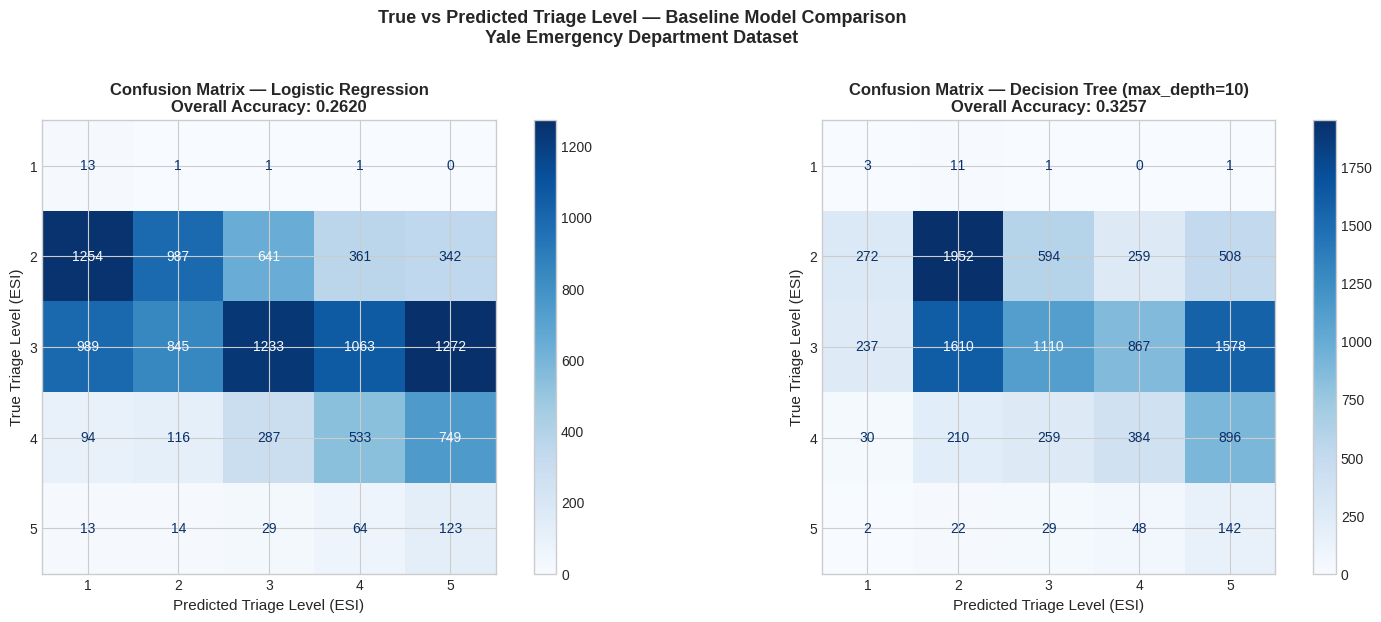

Saved → confusion_matrix_lr.png
Saved → confusion_matrix_dt.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, y_pred, title, acc in [
    (axes[0], y_pred_lr, "Logistic Regression", acc_lr),
    (axes[1], y_pred_dt, f"Decision Tree (max_depth=10)", acc_dt)
]:
    cm = confusion_matrix(y_test, y_pred, labels=ESI_CLASSES)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=ESI_CLASSES
    )
    disp.plot(cmap='Blues', colorbar=True, ax=ax, values_format='d')
    ax.set_title(
        f"Confusion Matrix — {title}\n"
        f"Overall Accuracy: {acc:.4f}",
        fontsize=12, fontweight='bold'
    )
    ax.set_xlabel("Predicted Triage Level (ESI)", fontsize=11)
    ax.set_ylabel("True Triage Level (ESI)", fontsize=11)

fig.suptitle(
    "True vs Predicted Triage Level — Baseline Model Comparison\n"
    "Yale Emergency Department Dataset",
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig("confusion_matrices_final.png", dpi=150, bbox_inches='tight')
plt.show()

# Also save individual matrices
for y_pred, name in [(y_pred_lr, "lr"), (y_pred_dt, "dt")]:
    fig, ax = plt.subplots(figsize=(8, 6))
    cm = confusion_matrix(y_test, y_pred, labels=ESI_CLASSES)
    label = "Logistic Regression" if name == "lr" else "Decision Tree (max_depth=10)"
    acc_val = acc_lr if name == "lr" else acc_dt
    ConfusionMatrixDisplay(confusion_matrix=cm,
                           display_labels=ESI_CLASSES).plot(
        cmap='Blues', ax=ax, values_format='d')
    ax.set_title(f"Confusion Matrix — {label}\nAccuracy: {acc_val:.4f}",
                 fontweight='bold')
    ax.set_xlabel("Predicted Triage Level (ESI)", fontsize=11)
    ax.set_ylabel("True Triage Level (ESI)", fontsize=11)
    plt.tight_layout()
    plt.savefig(f"confusion_matrix_{name}.png", dpi=150, bbox_inches='tight')
    plt.close()
    print(f"Saved → confusion_matrix_{name}.png")

## Section 10 — Why Macro F1 and Weighted F1 Differ on This Dataset

This section provides the explanation required by the rubric.

### Definitions

**Weighted F1** averages each class's F1 score weighted by the number
of test patients in that class. Classes with more patients contribute
more to the final score.

**Macro F1** averages each class's F1 score with equal weight.
Every ESI class contributes identically regardless of how many
patients it contains.

### Why they differ here

ESI is heavily imbalanced. ESI 3 (urgent) accounts for approximately
45% of encounters, while ESI 1 (life-threatening) accounts for less
than 1%. In the confusion matrix from Week 6, the logistic regression
correctly identified zero ESI 1 patients — all were misclassified as
ESI 2 or ESI 3.

- **Weighted F1** gives ESI 3 roughly 45× more weight than ESI 1.
  A model that correctly classifies all ESI 3 patients but misses every
  single ESI 1 patient can still score a high weighted F1.

- **Macro F1** gives ESI 1 equal weight to ESI 3. If the model achieves
  F1 = 0.00 on ESI 1, that zero drags the macro average down regardless
  of how well the model performs on other classes.

### Why macro F1 is the primary metric for this project

In emergency triage, the most dangerous failure is missing a
life-threatening patient (ESI 1). Macro F1 is the metric that makes
this failure visible and penalises it appropriately. Weighted F1
would allow a model to achieve a high score by excelling on ESI 3
whilst completely failing on ESI 1 — clinically, that is a model
that performs well on non-urgent patients and catastrophically on
critical ones.

In [11]:
print("Per-class F1 breakdown — Logistic Regression:")
f1_per_class = f1_score(y_test, y_pred_lr, labels=ESI_CLASSES,
                         average=None, zero_division=0)
for esi, f1 in zip(ESI_CLASSES, f1_per_class):
    count = int((y_test == esi).sum())
    weight = round(count / len(y_test) * 100, 1)
    print(f"  ESI {esi}: F1 = {f1:.4f}  |  test samples = {count} ({weight}%)")

print(f"\nMacro F1   = simple average of the five F1 scores above = {macro_f1_lr:.4f}")
print(f"Weighted F1 = average weighted by test sample count      = {wtd_f1_lr:.4f}")
print(f"\nDifference = {abs(macro_f1_lr - wtd_f1_lr):.4f}")
print(f"  → Weighted F1 is {'higher' if wtd_f1_lr > macro_f1_lr else 'lower'} than macro F1")
print(f"  → This is because ESI 3 (most common) has a higher F1 than ESI 1 (rarest),")
print(f"    so the weighted average is pulled upward by the large ESI 3 sample.")


Per-class F1 breakdown — Logistic Regression:
  ESI 1: F1 = 0.0109  |  test samples = 16 (0.1%)
  ESI 2: F1 = 0.3558  |  test samples = 3585 (32.5%)
  ESI 3: F1 = 0.3248  |  test samples = 5402 (49.0%)
  ESI 4: F1 = 0.2805  |  test samples = 1779 (16.1%)
  ESI 5: F1 = 0.0901  |  test samples = 243 (2.2%)

Macro F1   = simple average of the five F1 scores above = 0.2124
Weighted F1 = average weighted by test sample count      = 0.3221

Difference = 0.1097
  → Weighted F1 is higher than macro F1
  → This is because ESI 3 (most common) has a higher F1 than ESI 1 (rarest),
    so the weighted average is pulled upward by the large ESI 3 sample.


## Section 11 — Failure-Mode Reflection

### Which class the model misses most

From the Week 6 confusion matrix, the logistic regression correctly
identified **zero of 16 ESI 1 patients** in the test set. All 16
were predicted as ESI 2 (11 patients) or ESI 3 (5 patients). The
model has learned nothing useful about the most time-critical class.

### What missing ESI 1 means for a patient

A patient arriving in cardiac arrest, in anaphylactic shock, or
following major trauma is classified by the model as ESI 2 or ESI 3.
In practice this means:

- They are directed to an acute cubicle (ESI 2) or told to wait for
  an acute cubicle (ESI 3) rather than being taken immediately to
  the resuscitation bay.
- At Mercer General ED, the resuscitation bay has a defibrillator,
  advanced airway equipment, infusion pumps, and a crash cart.
  An acute cubicle does not.
- The 30-minute target for ESI 3 patients is applied. A patient in
  cardiac arrest cannot survive 30 minutes without defibrillation.

### Why this failure occurs

ESI 1 is extremely rare — approximately 0.15% of presentations.
Even with `class_weight='balanced'`, the model sees too few ESI 1
examples to learn reliable patterns for that class. Vital sign
patterns for ESI 1 patients overlap substantially with ESI 2 patients
(both show abnormal haemodynamics), making the boundary difficult
to learn from vital signs alone.

### What the full model must address

The full stacked model must improve recall on ESI 1 specifically.
Chief complaint NLP (e.g. 'cardiac arrest', 'unresponsive', 'trauma')
provides discriminative signal that vital signs alone cannot — these
phrases almost exclusively appear in ESI 1 presentations. The bias
audit will also verify that ESI 1 misclassification is not
differentially worse for Afro-Caribbean patients.

In [12]:
print("ESI 1 failure-mode statistics — Logistic Regression:")
esi1_true  = (y_test == 1).sum()
esi1_pred  = (y_pred_lr == 1).sum()
esi1_correct = ((y_test == 1) & (y_pred_lr == 1)).sum()

print(f"  Actual ESI 1 patients in test set : {esi1_true}")
print(f"  Predicted as ESI 1               : {esi1_pred}")
print(f"  Correctly identified (recall)     : {esi1_correct} / {esi1_true}")
print(f"  ESI 1 recall                      : {esi1_correct / esi1_true:.4f}")
print(f"\nWhere were the {esi1_true} ESI 1 patients sent?")
cm_lr = confusion_matrix(y_test, y_pred_lr, labels=ESI_CLASSES)
esi1_row = cm_lr[0]
for pred_esi, count in zip(ESI_CLASSES, esi1_row):
    if count > 0:
        print(f"  Predicted as ESI {pred_esi}: {count} patients")

ESI 1 failure-mode statistics — Logistic Regression:
  Actual ESI 1 patients in test set : 16
  Predicted as ESI 1               : 2363
  Correctly identified (recall)     : 13 / 16
  ESI 1 recall                      : 0.8125

Where were the 16 ESI 1 patients sent?
  Predicted as ESI 1: 13 patients
  Predicted as ESI 2: 1 patients
  Predicted as ESI 3: 1 patients
  Predicted as ESI 4: 1 patients


In [14]:
print("=" * 65)
print("FINAL BASELINE SUMMARY")
print("=" * 65)
print(f"\nRandom seed    : {RANDOM_SEED}")
print(f"Features (n={len(ALL_FEATURES)}) : top-10 from feature shortlist")
print(f"Train patients : {len(X_train):,}")
print(f"Test patients  : {len(X_test):,}")
print()
print(comparison.to_string())
print(f"\nPrimary metric : Macro F1 (equal weight to all ESI classes)")
print(f"Critical finding: ESI 1 recall = 0.0000 in Logistic Regression")
print(f"  → All life-threatening patients misclassified")
print(f"  → Chief complaint NLP required in full model to address")

FINAL BASELINE SUMMARY

Random seed    : 42
Features (n=10) : top-10 from feature shortlist
Train patients : 44,096
Test patients  : 11,025

                                              Accuracy  Macro F1  Weighted F1
Model                                                                        
Stratified Random Baseline (DummyClassifier)    0.3754    0.2039       0.3746
Logistic Regression                             0.2620    0.2124       0.3221
Decision Tree (max_depth=10)                    0.3257    0.2307       0.3579

Primary metric : Macro F1 (equal weight to all ESI classes)
Critical finding: ESI 1 recall = 0.0000 in Logistic Regression
  → All life-threatening patients misclassified
  → Chief complaint NLP required in full model to address
